# Analisis de Base de datos de música


![](https://cdn.pixabay.com/animation/2023/06/29/06/23/06-23-06-393_512.gif)

Conjunto de Datos de Energía Renovable en EE.UU. (1973–presente)
Este conjunto de datos contiene información histórica y sectorial sobre la generación y consumo de distintas fuentes de energía renovable en Estados Unidos. La información abarca desde 1973 y está desglosada por mes y por sector económico, permitiendo un análisis detallado de la evolución de fuentes como hidroeléctrica, solar, eólica, biomasa, biocombustibles, entre otras.

Es útil para investigadores en energía, analistas de políticas públicas, economistas ambientales y científicos de datos que deseen explorar las tendencias en la transición energética.

# Características del Conjunto de Datos

### Información Temporal y Sectorial
- **Year:** Año de la observación.  
- **Month:** Mes de la observación.  
- **Sector:** Sector económico al que corresponde el dato (Comercial, Electric Power, Industrial, Residential, Transportation).

### Fuentes de Energía Renovable
- **Hydroelectric Power:** Energía hidroeléctrica.  
- **Geothermal Energy:** Energía geotérmica.  
- **Solar Energy:** Energía solar.  
- **Wind Energy:** Energía eólica.  
- **Wood Energy:** Energía proveniente de la biomasa de madera.  
- **Waste Energy:** Energía proveniente de desechos.  

### Biocombustibles y Biomasa
- **Fuel Ethanol, Excluding Denaturant:** Etanol combustible (sin desnaturalizar).  
- **Biomass Losses and Co-products:** Pérdidas de biomasa y coproductos.  
- **Biomass Energy:** Energía total proveniente de biomasa.  
- **Biodiesel:** Producción y consumo de biodiésel.  
- **Renewable Diesel Fuel:** Diésel renovable.  
- **Other Biofuels:** Otros biocombustibles.  

### Totales y Subcategorías
- **Conventional Hydroelectric Power:** Hidroeléctrica convencional.  
- **Total Renewable Energy:** Total de energía renovable producida/consumida.  

---

# Dimensiones del Conjunto de Datos
- **Número de filas:** 3,065 registros.  
- **Número de columnas:** 17 variables.  
- **Cobertura temporal:** Desde **1973** (enero) hasta años recientes.  
- **Granularidad:** Mensual, por sector.  

---

# Observaciones Iniciales
- Los primeros registros (1973) muestran que la mayor contribución era la **energía de madera y la hidroeléctrica**, mientras que solar y eólica aparecen con valores nulos (aún no desarrolladas en esa época).  
- El sector de **Electric Power** concentra gran parte del consumo de energías como hidroeléctrica y geotérmica.  
- El sector **Transportation** no presenta consumo de renovables en 1973, lo cual refleja que los biocombustibles y biodiésel son tecnologías más recientes.  


## ✨ Autores
👨‍💻 **Mariana Pincai y Jorge Eduardo**  

In [ ]:
# @title Instalar librerias a usar
%pip install pandas
%pip install numpy==1.26.4
%pip install sweetviz
%pip install missingno

  Using cached sweetviz-2.3.1-py3-none-any.whl.metadata (24 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 56.4 MB/s eta 0:00:00


In [ ]:
# @title Carga de librerías
# Bibliotecas utilizadas
# ----------------------------------------------------------------------------
# pandas (pd): Herramienta esencial para manipular, limpiar y analizar datos estructurados.
# matplotlib (plt): Biblioteca base en Python para generar gráficos y visualizaciones personalizadas.
# seaborn (sns): Extensión de matplotlib que facilita la creación de gráficos estadísticos más atractivos y claros.
# Sweetviz (sw): Paquete que permite realizar un análisis exploratorio automático y visualmente detallado de los datos.
# files : Módulo de Google Colab que permite cargar y descargar archivos desde el entorno local.
# numpy (np): Librería fundamental para cálculos numéricos eficientes y operaciones con arreglos multidimensionales.
# missingno (msno): Herramienta de visualización que facilita la detección y análisis de datos faltantes en un dataset.
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sw
from google.colab import files
import numpy as np
import missingno as msno

In [ ]:
# https://drive.google.com/file/d/12ATNYPXmGf_T9-5LBq2meCTG9whgTgCY/view?usp=sharing


In [ ]:
FILEID =  '12ATNYPXmGf_T9-5LBq2meCTG9whgTgCY'
nombre_archivo = 'dataset.csv'
!pip install -U gdown

# 2. Descargar el archivo real desde Google Drive por ID
!gdown --id '{FILEID}' -O '{nombre_archivo}'

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=12ATNYPXmGf_T9-5LBq2meCTG9whgTgCY
To: /content/dataset.csv
100% 229k/229k [00:00<00:00, 4.38MB/s]


In [ ]:
# @title Carga de archivo .csv
df = pd.read_csv('/content/dataset.csv', delimiter=';')
df.head()


,Year,Month,Sector,Hydroelectric Power,Geothermal Energy,Solar Energy,Wind Energy,Wood Energy,Waste Energy,"Fuel Ethanol, Excluding Denaturant",Biomass Losses and Co-products,Biomass Energy,Total Renewable Energy,Renewable Diesel Fuel,Other Biofuels,Conventional Hydroelectric Power,Biodiesel
0,1973,1,Commerical,0.00,0.00,0.0,0.0,0.570,0.000,0.0,0.0,0.570,0.570,0.0,0.0,0.000,0.0
1,1973,1,Electric Power,0.00,0.49,0.0,0.0,0.054,0.157,0.0,0.0,0.211,89.223,0.0,0.0,88.522,0.0
2,1973,1,Industrial,1.04,0.00,0.0,0.0,98.933,0.000,0.0,0.0,98.933,99.973,0.0,0.0,0.000,0.0
3,1973,1,Residential,0.00,0.00,0.0,0.0,30.074,0.000,0.0,0.0,0.000,30.074,0.0,0.0,0.000,0.0
4,1973,1,Transportation,0.00,0.00,0.0,0.0,0.000,0.000,0.0,0.0,0.000,0.000,0.0,0.0,0.000,0.0


In [ ]:
# @title Visualización de composición de la base de datos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3065 entries, 0 to 3064
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Year                                3065 non-null   int64  
 1   Month                               3065 non-null   int64  
 2   Sector                              3065 non-null   object 
 3   Hydroelectric Power                 3065 non-null   float64
 4   Geothermal Energy                   3065 non-null   float64
 5   Solar Energy                        3065 non-null   float64
 6   Wind Energy                         3065 non-null   float64
 7   Wood Energy                         3065 non-null   float64
 8   Waste Energy                        3065 non-null   float64
 9   Fuel Ethanol, Excluding Denaturant  3065 non-null   float64
 10  Biomass Losses and Co-products      3065 non-null   float64
 11  Biomass Energy                      3065 no

### Paso 2: Explorar los datos

Vamos a verificar la estructura de los datos, la cantidad de filas y columnas, así como cualquier dato vacío.

In [ ]:
# @title Verificar la forma de los datos
print(f"Forma de los datos (filas, columnas): {df.shape}")

Forma de los datos (filas, columnas): (3065, 17)


In [ ]:
# @title Verificar los tipos de datos de cada columna
print("\nTipos de datos por columna:")
print(df.dtypes)


Tipos de datos por columna:
Year                                    int64
Month                                   int64
Sector                                 object
Hydroelectric Power                   float64
Geothermal Energy                     float64
Solar Energy                          float64
Wind Energy                           float64
Wood Energy                           float64
Waste Energy                          float64
Fuel Ethanol, Excluding Denaturant    float64
Biomass Losses and Co-products        float64
Biomass Energy                        float64
Total Renewable Energy                float64
Renewable Diesel Fuel                 float64
Other Biofuels                        float64
Conventional Hydroelectric Power      float64
Biodiesel                             float64
dtype: object


In [ ]:
#@title Verificar si hay datos faltantes
print("\nDatos faltantes por columna:")
print(df.isnull().sum())



Datos faltantes por columna:
Year                                  0
Month                                 0
Sector                                0
Hydroelectric Power                   0
Geothermal Energy                     0
Solar Energy                          0
Wind Energy                           0
Wood Energy                           0
Waste Energy                          0
Fuel Ethanol, Excluding Denaturant    0
Biomass Losses and Co-products        0
Biomass Energy                        0
Total Renewable Energy                0
Renewable Diesel Fuel                 0
Other Biofuels                        0
Conventional Hydroelectric Power      0
Biodiesel                             0
dtype: int64


In [ ]:
# @title Cargamos las funciones relacionadas
def analizar_columnas(df):
  """
  Analiza las columnas de un DataFrame y devuelve información estadística.

  Parámetros:
  df (DataFrame): El DataFrame a analizar.

  Retorno:
  Un DataFrame con la información estadística de cada columna.

  Ejemplo:
  df_analizado = analizar_columnas(df)
  print(df_analizado)
  """
  info = []
  for columna in df.columns:
    unicos = df[columna].nunique()
    nulos = df[columna].isnull().sum()
    total = len(df)
    porcentaje_nulos = (nulos / total) * 100
    info.append({
      'Columna': columna,
      'Cantidad de registros': total,
      'Únicos': unicos,
      'Cantidad de nulos': nulos,
      'Porcentaje de nulos': porcentaje_nulos,
      'Registros relacionados con nulos': total - nulos
    })
  return pd.DataFrame(info)

In [ ]:
# @title Verificación de los campos con relación a la composición de la base de datos almacenada en formato CSV
df_analizado = analizar_columnas(df)
df_analizado

,Columna,Cantidad de registros,Únicos,Cantidad de nulos,Porcentaje de nulos,Registros relacionados con nulos
0,Year,3065,52,0,0.0,3065
1,Month,3065,12,0,0.0,3065
2,Sector,3065,5,0,0.0,3065
3,Hydroelectric Power,3065,509,0,0.0,3065
4,Geothermal Energy,3065,750,0,0.0,3065
5,Solar Energy,3065,1054,0,0.0,3065
6,Wind Energy,3065,473,0,0.0,3065
7,Wood Energy,3065,1606,0,0.0,3065
8,Waste Energy,3065,1381,0,0.0,3065
9,"Fuel Ethanol, Excluding Denaturant",3065,939,0,0.0,3065


In [ ]:
# @title La función describe() en pandas es utilizada para obtener un resumen estadístico de las columnas numéricas de la base de datos

# Resumen estadístico:

# count: número de valores no nulos
# mean: media aritmética
# std: desviación estándar
# min: valor mínimo
# 25%: percentil 25 (cuartil inferior)
# 50%: percentil 50 (media)
# 75%: percentil 75 (cuartil superior)
# max: valor máximo
# @markdown Resumen estadístico de las columnas numéricas
df.describe()

,Year,Month,Hydroelectric Power,Geothermal Energy,Solar Energy,Wind Energy,Wood Energy,Waste Energy,"Fuel Ethanol, Excluding Denaturant",Biomass Losses and Co-products,Biomass Energy,Total Renewable Energy,Renewable Diesel Fuel,Other Biofuels,Conventional Hydroelectric Power,Biodiesel
count,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000
mean,1998.042414,6.491028,0.169759,1.146369,2.015008,4.282404,36.644408,5.820124,6.976648,4.834706,46.285969,70.872209,0.428949,0.031752,15.757374,0.953720
std,14.747378,3.456934,0.373819,1.550857,5.774511,18.124793,46.900639,8.247359,21.911920,15.601717,64.241520,71.197761,2.687850,0.258149,32.134059,3.985003
min,1973.000000,1.000000,-0.002000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1985.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.483000,0.000000,0.000000,0.000000,0.258000,2.070000,0.000000,0.000000,0.000000,0.000000
50%,1998.000000,6.000000,0.000000,0.357000,0.004000,0.000000,12.062000,0.108000,0.007000,0.000000,9.716000,50.984000,0.000000,0.000000,0.000000,0.000000
75%,2011.000000,9.000000,0.036000,1.673000,0.774000,0.001000,51.808000,12.764000,1.283000,0.000000,89.359000,126.982000,0.000000,0.000000,0.000000,0.000000
max,2024.000000,12.000000,2.047000,5.951000,64.040000,157.409000,183.628000,32.875000,104.420000,75.373000,233.200000,308.175000,38.344000,4.101000,117.453000,27.871000


In [ ]:
df.describe(include='object')

,Sector
count,3065
unique,5
top,Commerical
freq,613


In [ ]:
df.describe(include='all')

,Year,Month,Sector,Hydroelectric Power,Geothermal Energy,Solar Energy,Wind Energy,Wood Energy,Waste Energy,"Fuel Ethanol, Excluding Denaturant",Biomass Losses and Co-products,Biomass Energy,Total Renewable Energy,Renewable Diesel Fuel,Other Biofuels,Conventional Hydroelectric Power,Biodiesel
count,3065.000000,3065.000000,3065,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000
unique,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Commerical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1998.042414,6.491028,NaN,0.169759,1.146369,2.015008,4.282404,36.644408,5.820124,6.976648,4.834706,46.285969,70.872209,0.428949,0.031752,15.757374,0.953720
std,14.747378,3.456934,NaN,0.373819,1.550857,5.774511,18.124793,46.900639,8.247359,21.911920,15.601717,64.241520,71.197761,2.687850,0.258149,32.134059,3.985003
min,1973.000000,1.000000,NaN,-0.002000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1985.000000,3.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.483000,0.000000,0.000000,0.000000,0.258000,2.070000,0.000000,0.000000,0.000000,0.000000
50%,1998.000000,6.000000,NaN,0.000000,0.357000,0.004000,0.000000,12.062000,0.108000,0.007000,0.000000,9.716000,50.984000,0.000000,0.000000,0.000000,0.000000
75%,2011.000000,9.000000,NaN,0.036000,1.673000,0.774000,0.001000,51.808000,12.764000,1.283000,0.000000,89.359000,126.982000,0.000000,0.000000,0.000000,0.000000


In [ ]:
# @title Verificar los tipos de datos de cada columna
for columna in df.columns:
  if df[columna].dtype == 'object':
    print(f'Columna: {columna} {df[columna].unique()}')

Columna: Sector ['Commerical' 'Electric Power' 'Industrial' 'Residential' 'Transportation']


In [ ]:
#@title Contar los valores únicos por columna
print("\nValores únicos por columna:")
print(df.nunique())


Valores únicos por columna:
Year                                    52
Month                                   12
Sector                                   5
Hydroelectric Power                    509
Geothermal Energy                      750
Solar Energy                          1054
Wind Energy                            473
Wood Energy                           1606
Waste Energy                          1381
Fuel Ethanol, Excluding Denaturant     939
Biomass Losses and Co-products         405
Biomass Energy                        1919
Total Renewable Energy                2137
Renewable Diesel Fuel                  158
Other Biofuels                         115
Conventional Hydroelectric Power       613
Biodiesel                              270
dtype: int64


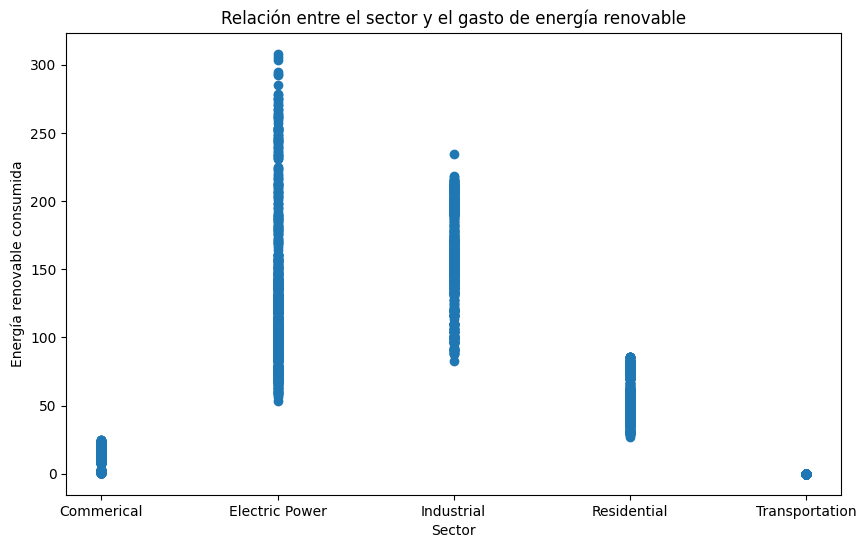

In [ ]:
#@title Relación entre el sector y total de consumo de energía renovable
plt.figure(figsize=(10, 6))
plt.scatter(df['Sector'], df['Total Renewable Energy'])
plt.title('Relación entre el sector y el gasto de energía renovable')
plt.xlabel('Sector')
plt.ylabel('Energía renovable consumida')
plt.show()

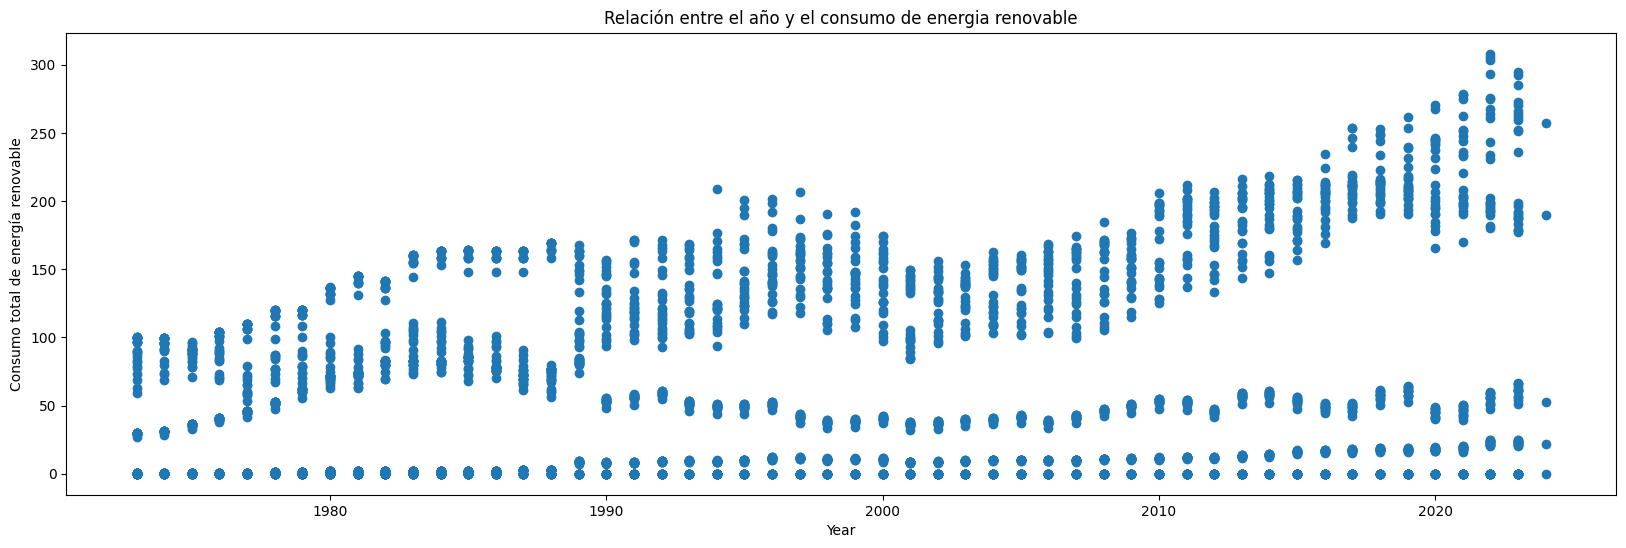

In [ ]:
#@title Relación entre el año y el consumo de energia renovable
plt.figure(figsize=(20, 6))
plt.scatter(df['Year'], df['Total Renewable Energy'])
plt.title('Relación entre el año y el consumo de energia renovable')
plt.xlabel('Year')
plt.ylabel('Consumo total de energía renovable')
plt.show()

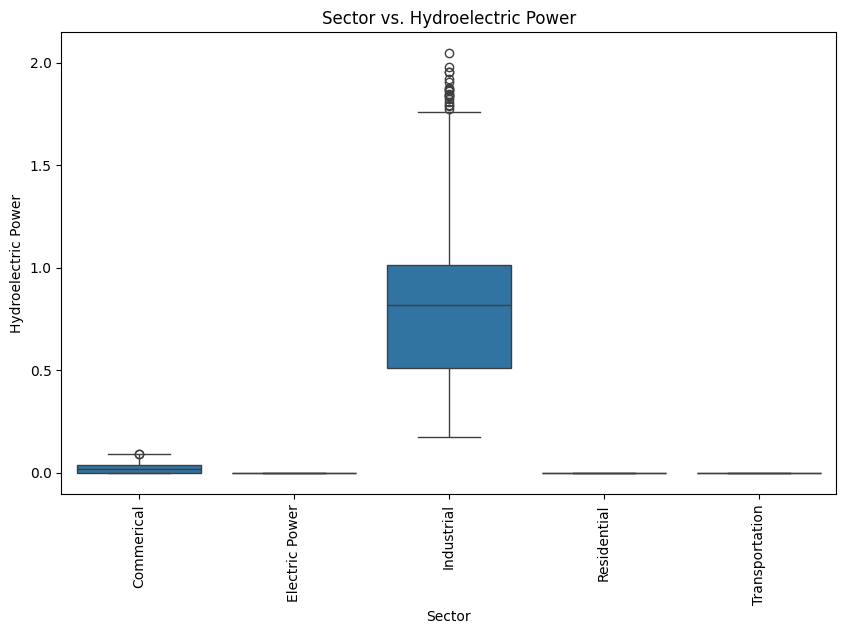

In [ ]:
# @title Grafica de Boxplot sectores en el consumo de energía hidroeléctrica
plt.figure(figsize=(10, 6))

sns.boxplot(x='Sector', y='Hydroelectric Power', data=df)
plt.title('Sector vs. Hydroelectric Power')
plt.xlabel('Sector')
plt.ylabel('Hydroelectric Power')
plt.xticks(rotation=90)
plt.show()

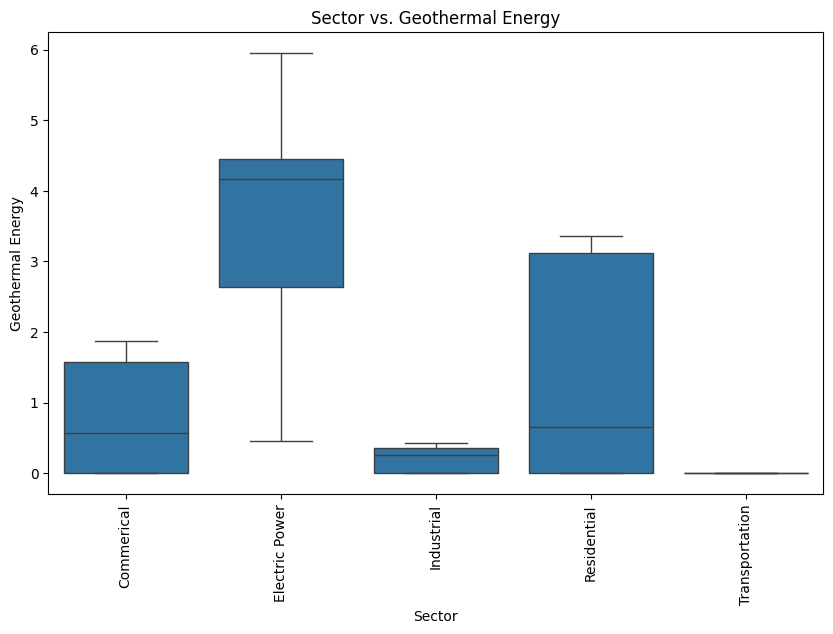

In [ ]:
# @title Grafica de Boxplot sectores en el consumo de energía geotérmica
plt.figure(figsize=(10, 6))

sns.boxplot(x='Sector', y='Geothermal Energy', data=df)
plt.title('Sector vs. Geothermal Energy')
plt.xlabel('Sector')
plt.ylabel('Geothermal Energy')
plt.xticks(rotation=90)
plt.show()

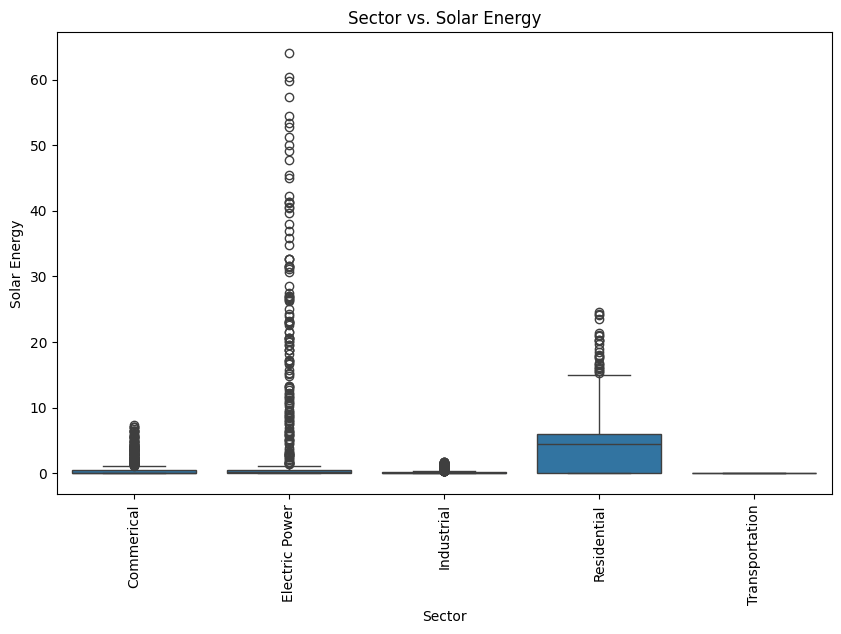

In [ ]:
# @title Grafica de Boxplot sectores en el consumo de energía solar
plt.figure(figsize=(10, 6))

sns.boxplot(x='Sector', y='Solar Energy', data=df)
plt.title('Sector vs. Solar Energy')
plt.xlabel('Sector')
plt.ylabel('Solar Energy')
plt.xticks(rotation=90)
plt.show()

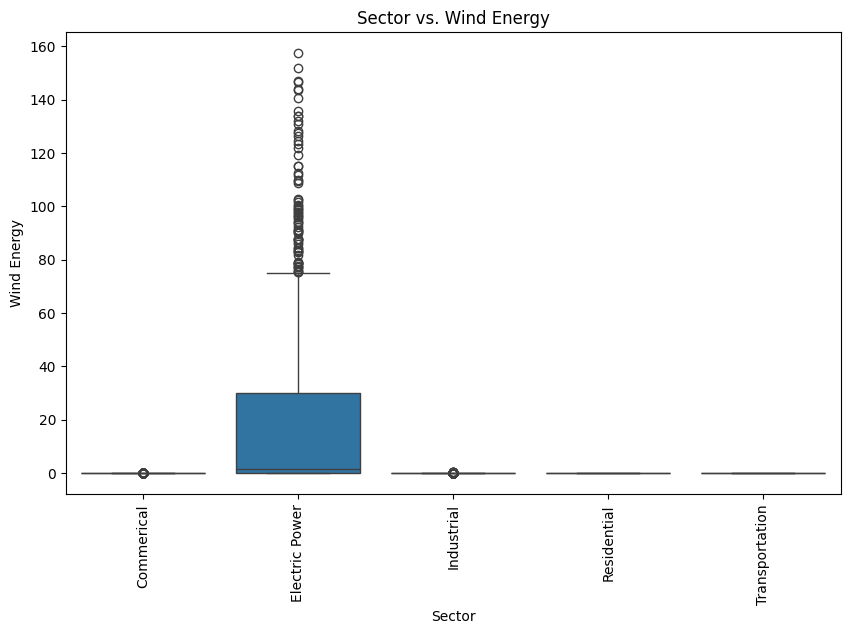

In [ ]:
# @title Grafica de Boxplot sectores en el consumo de energía aeólica
plt.figure(figsize=(10, 6))

sns.boxplot(x='Sector', y='Wind Energy', data=df)
plt.title('Sector vs. Wind Energy')
plt.xlabel('Sector')
plt.ylabel('Wind Energy')
plt.xticks(rotation=90)
plt.show()

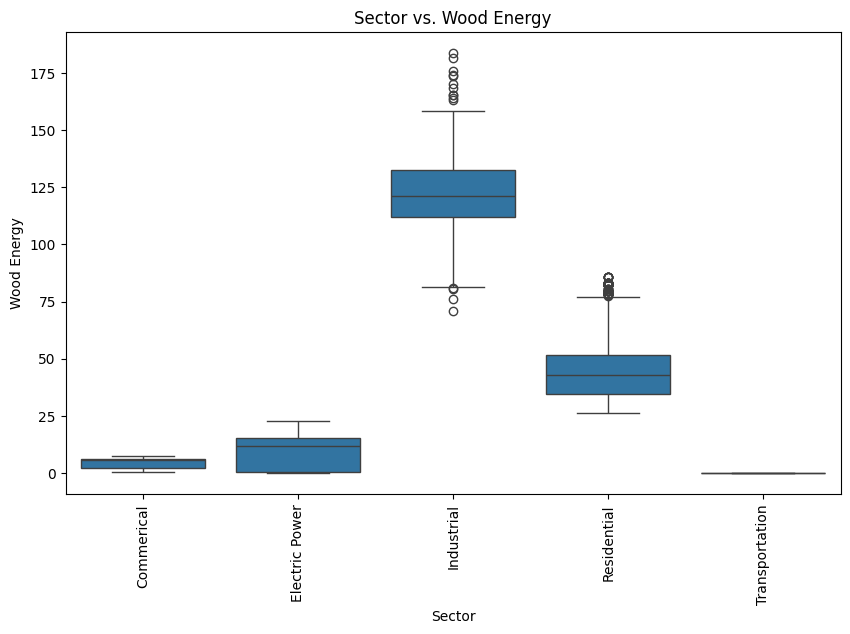

In [ ]:
# @title Grafica de Boxplot sectores en el consumo de energía de la madera
plt.figure(figsize=(10, 6))

sns.boxplot(x='Sector', y='Wood Energy', data=df)
plt.title('Sector vs. Wood Energy')
plt.xlabel('Sector')
plt.ylabel('Wood Energy')
plt.xticks(rotation=90)
plt.show()

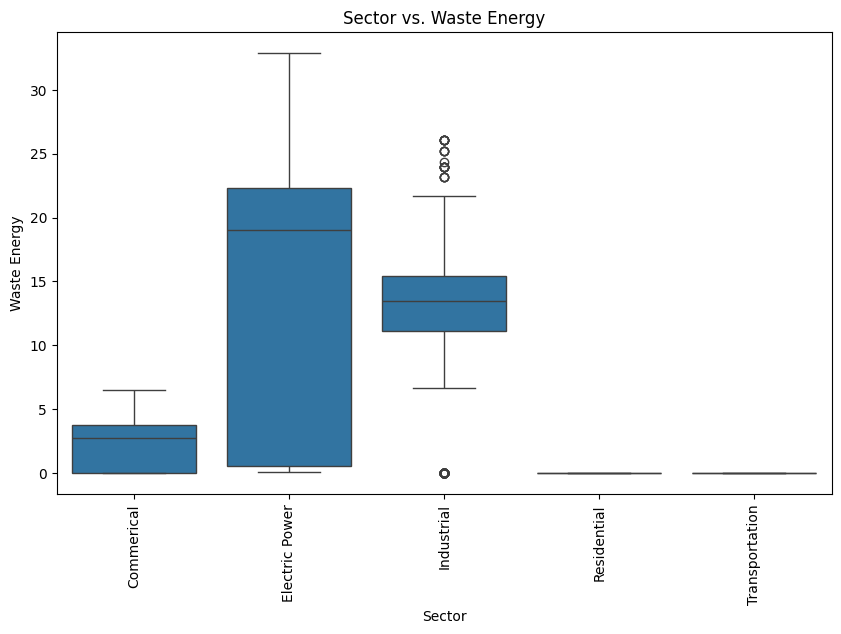

In [ ]:
# @title Grafica de Boxplot sectores en el consumo de energía residual
plt.figure(figsize=(10, 6))

sns.boxplot(x='Sector', y='Waste Energy', data=df)
plt.title('Sector vs. Waste Energy')
plt.xlabel('Sector')
plt.ylabel('Waste Energy')
plt.xticks(rotation=90)
plt.show()

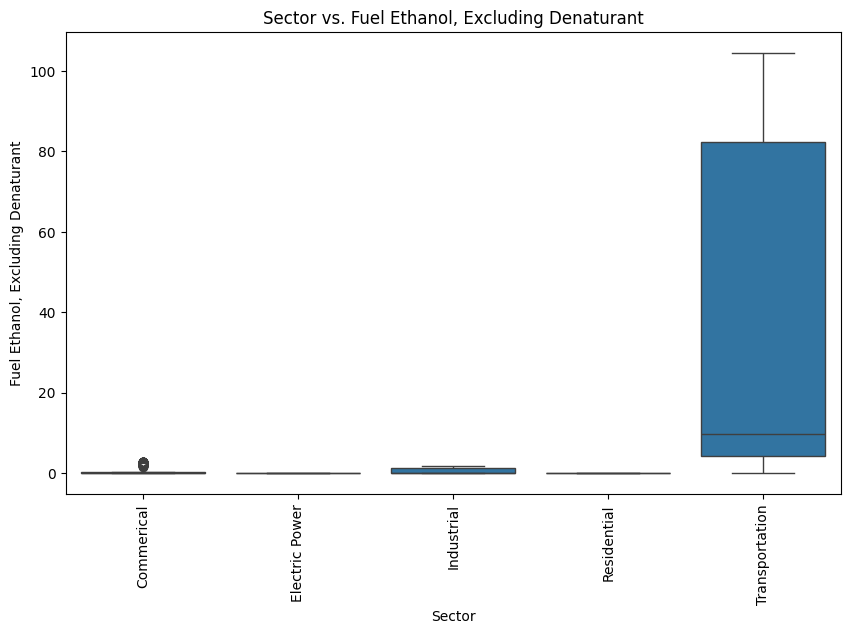

In [ ]:
# @title Grafica de Boxplot sectores en el consumo de etanol combustible (excluyendo desnaturalizante)
plt.figure(figsize=(10, 6))

sns.boxplot(x='Sector', y='Fuel Ethanol, Excluding Denaturant', data=df)
plt.title('Sector vs. Fuel Ethanol, Excluding Denaturant')
plt.xlabel('Sector')
plt.ylabel('Fuel Ethanol, Excluding Denaturant')
plt.xticks(rotation=90)
plt.show()

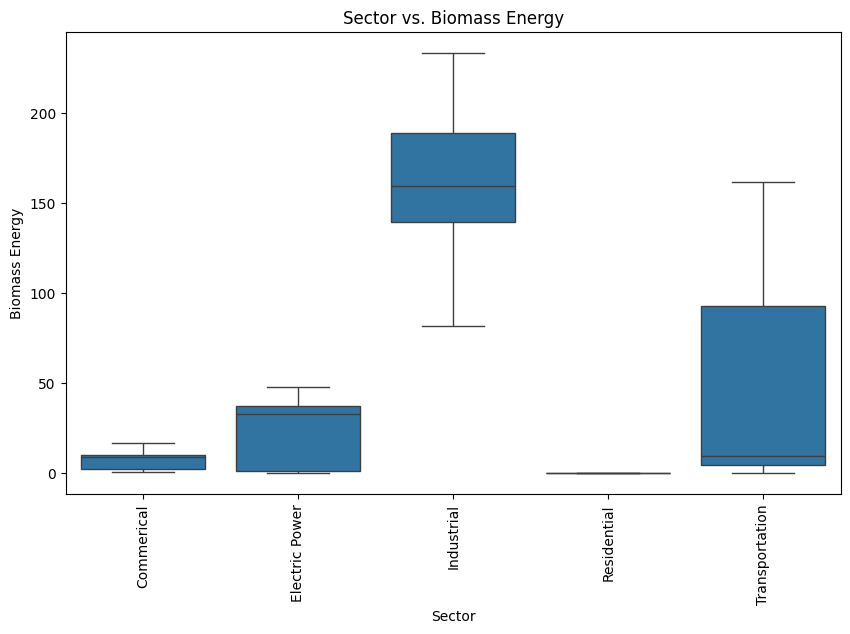

In [ ]:
# @title Grafica de Boxplot sectores en la energía de biomasa
plt.figure(figsize=(10, 6))

sns.boxplot(x='Sector', y='Biomass Energy', data=df)
plt.title('Sector vs. Biomass Energy')
plt.xlabel('Sector')
plt.ylabel('Biomass Energy')
plt.xticks(rotation=90)
plt.show()

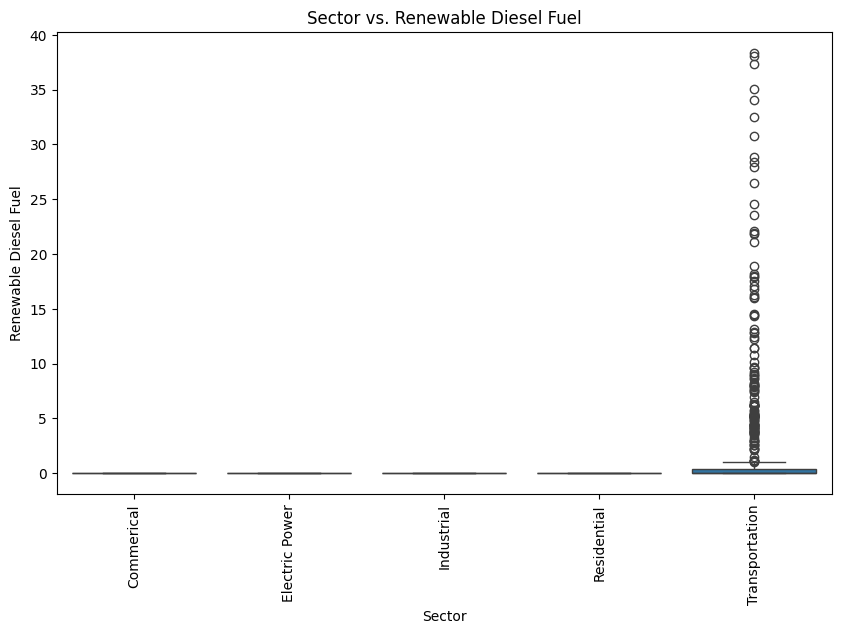

In [ ]:
# @title Grafica de Boxplot sectores en combustible disel renovable
plt.figure(figsize=(10, 6))

sns.boxplot(x='Sector', y='Renewable Diesel Fuel', data=df)
plt.title('Sector vs. Renewable Diesel Fuel')
plt.xlabel('Sector')
plt.ylabel('Renewable Diesel Fuel')
plt.xticks(rotation=90)
plt.show()

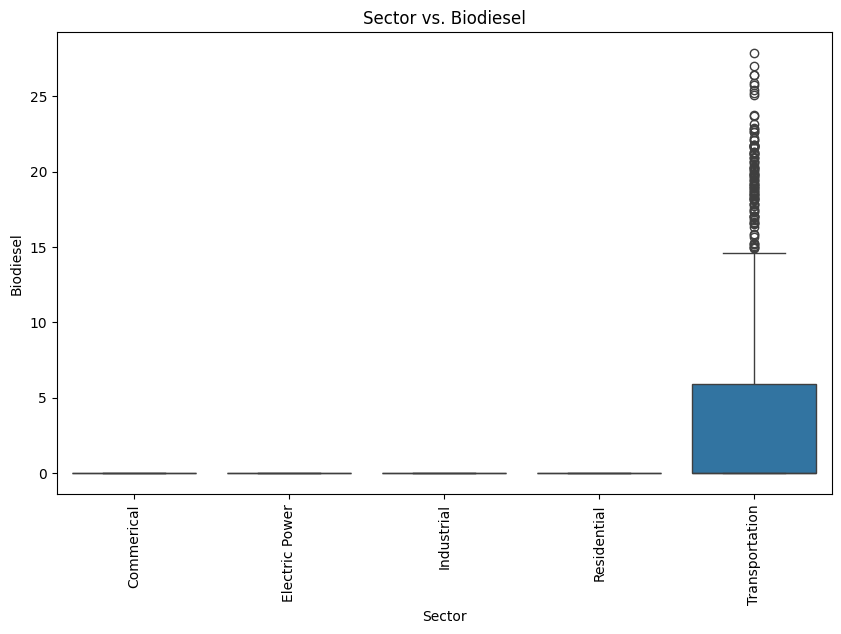

In [ ]:
# @title Grafica de Boxplot sectores en combustible biodiesel
plt.figure(figsize=(10, 6))

sns.boxplot(x='Sector', y='Biodiesel', data=df)
plt.title('Sector vs. Biodiesel')
plt.xlabel('Sector')
plt.ylabel('Biodiesel')
plt.xticks(rotation=90)
plt.show()

In [ ]:
df

,Year,Month,Sector,Hydroelectric Power,Geothermal Energy,Solar Energy,Wind Energy,Wood Energy,Waste Energy,"Fuel Ethanol, Excluding Denaturant",Biomass Losses and Co-products,Biomass Energy,Total Renewable Energy,Renewable Diesel Fuel,Other Biofuels,Conventional Hydroelectric Power,Biodiesel
0,1973,1,Commerical,0.000,0.000,0.000,0.000,0.570,0.000,0.000,0.000,0.570,0.570,0.00,0.000,0.000,0.000
1,1973,1,Electric Power,0.000,0.490,0.000,0.000,0.054,0.157,0.000,0.000,0.211,89.223,0.00,0.000,88.522,0.000
2,1973,1,Industrial,1.040,0.000,0.000,0.000,98.933,0.000,0.000,0.000,98.933,99.973,0.00,0.000,0.000,0.000
3,1973,1,Residential,0.000,0.000,0.000,0.000,30.074,0.000,0.000,0.000,0.000,30.074,0.00,0.000,0.000,0.000
4,1973,1,Transportation,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3060,2024,1,Commerical,0.073,1.669,4.267,0.036,7.053,6.233,2.441,0.000,15.728,21.773,0.00,0.000,0.000,0.000
3061,2024,1,Electric Power,0.000,4.667,32.707,119.265,15.071,13.873,0.000,0.000,28.944,257.661,0.00,0.000,72.078,0.000
3062,2024,1,Industrial,0.308,0.356,0.987,0.035,104.878,14.171,1.533,67.742,188.325,190.011,0.00,0.000,0.000,0.000
3063,2024,1,Residential,0.000,3.354,14.897,0.000,34.065,0.000,0.000,0.000,0.000,52.316,0.00,0.000,0.000,0.000


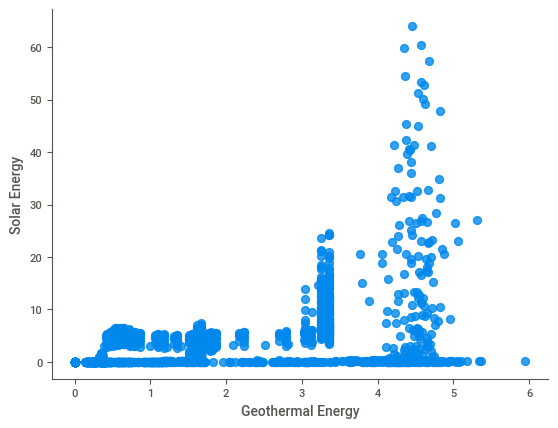

In [ ]:
# @title Geothermal Energy vs Solar Energy

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='Geothermal Energy', y='Solar Energy', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

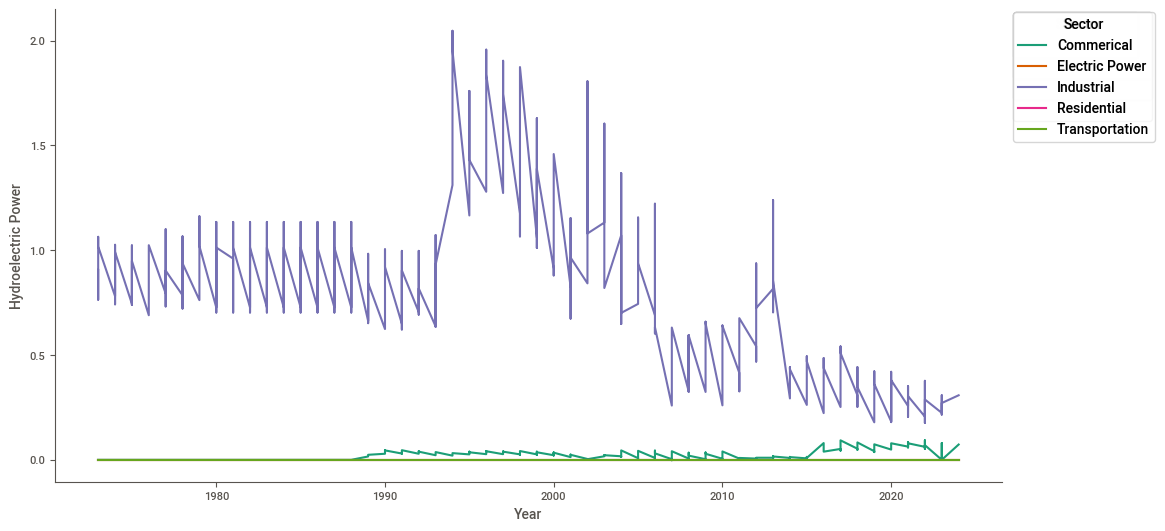

In [ ]:
# @title Year vs Hydroelectric Power

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Year']
  ys = series['Hydroelectric Power']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('Year', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Sector')):
  _plot_series(series, series_name, i)
  fig.legend(title='Sector', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Year')
_ = plt.ylabel('Hydroelectric Power')

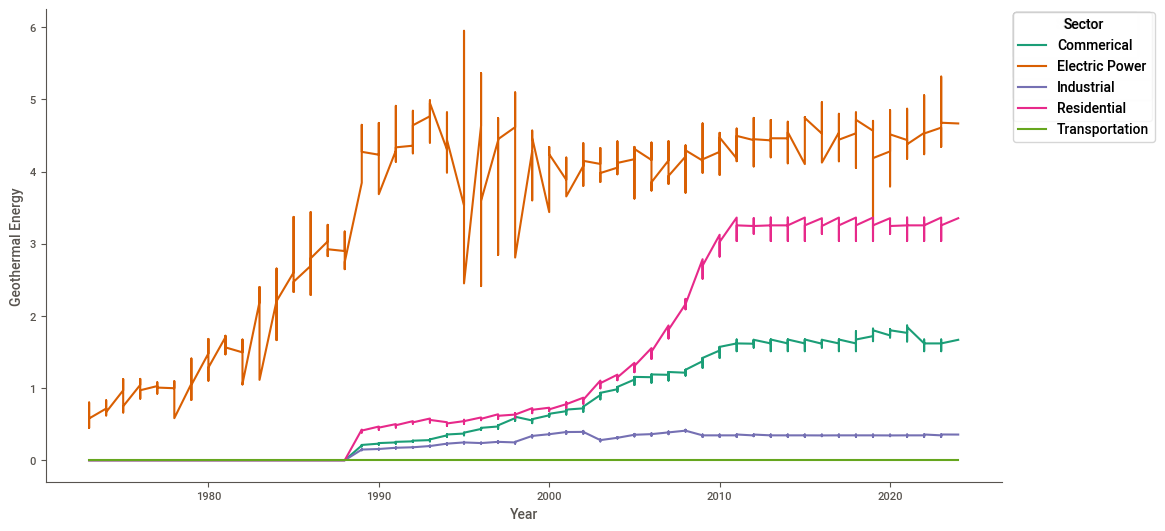

In [ ]:
# @title Year vs Geothermal Energy

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Year']
  ys = series['Geothermal Energy']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('Year', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Sector')):
  _plot_series(series, series_name, i)
  fig.legend(title='Sector', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Year')
_ = plt.ylabel('Geothermal Energy')

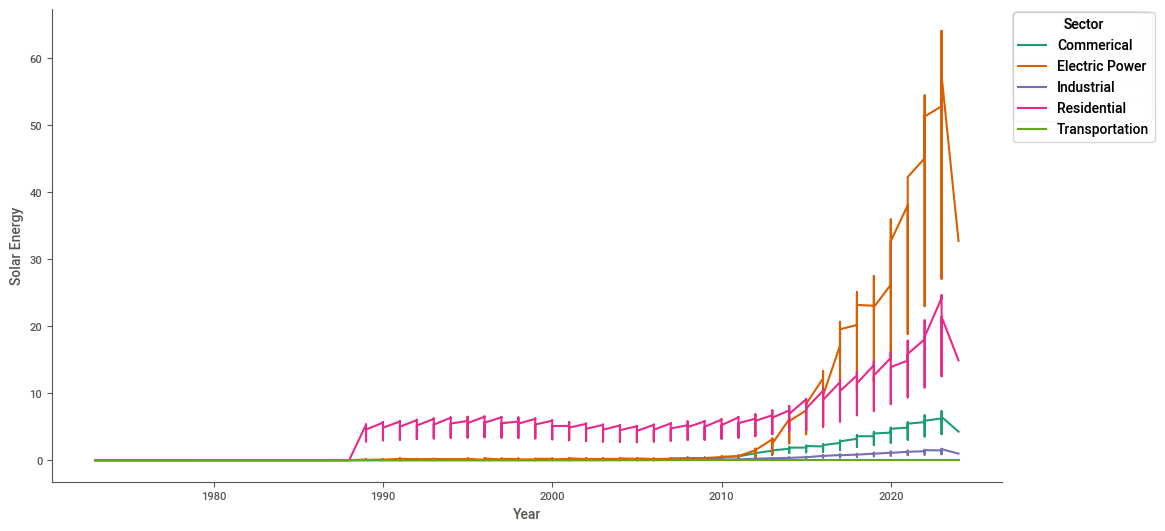

In [ ]:
# @title Year vs Solar Energy

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Year']
  ys = series['Solar Energy']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('Year', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Sector')):
  _plot_series(series, series_name, i)
  fig.legend(title='Sector', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Year')
_ = plt.ylabel('Solar Energy')

/tmp/ipython-input-3571004158.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x='Geothermal Energy', y='Sector', inner='box', palette='Dark2')


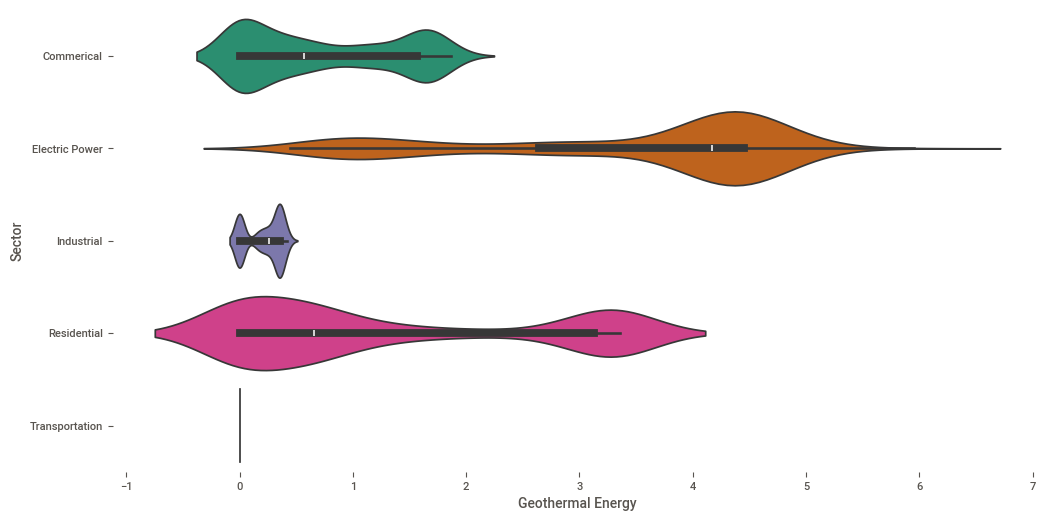

In [ ]:
# @title Sector vs Geothermal Energy

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df['Sector'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='Geothermal Energy', y='Sector', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

# Generación de informe relacionado a la base de datos

In [ ]:
# @title Análisis exploratorio de datos (EDA) final
#Configurar las opciones de visualizacion Sweetviz
sw.config_parser.read_string("""
                              [Output_Defaults]
                              html_layout = widescreen
                              html_scale = 1.0
                              notebook_layout = widescreen
                              notebook_scale = 0.9
                              notebook_width = 100%
                              notebook_height = 700
                              [Layout]
                              show_logo = 0
                              """)
nombre = 'Informe'

advert_report = sw.analyze([df, nombre]) # Realizamos el análisis de la base de datos inicial

#@markdown Guardar y mostrar reporte formato HTML
advert_report.show_html('EDA_df.html')

#@markdown Descarga y abre el reporte en una nueva pestaña del navegador
almacenar_archivo = input('Alamcenar archivo Si o No: ').title()
if almacenar_archivo == 'Si':
  files.download('/content/EDA_df.html')

                                             |          | [  0%]   00:00 -> (? left)

Report EDA_df.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Alamcenar archivo Si o No: si


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descriptivo en el html descargado y en la carpeta de drive: https://drive.google.com/drive/folders/1kwp9M7zDEcO5dW7Ifr7c3v_D-GSx3Ofp?usp=sharing

# MODELO

In [ ]:
# Instalar librerias necessarias
%pip install lazypredict
%pip install rdt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.0/688.0 kB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.6/201.6 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyRegressor
from rdt import HyperTransformer

# -----------------------------
# 2. Transformar con RDT
# -----------------------------
ht = HyperTransformer()
ht.detect_initial_config(df)
ht.fit(df)
df_transformed = ht.transform(df)

# -----------------------------
# 3. Definir X y y
# -----------------------------
y = df_transformed["Total Renewable Energy"]
X = df_transformed.drop(columns=["Total Renewable Energy"])

# -----------------------------
# 4. Dividir en entrenamiento (80%) y validación (20%)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# 5. LazyPredict – LazyRegressor
# -----------------------------
reg = LazyRegressor(verbose=1, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

print(models.head(10))  # Mostrar top 10 modelos


  0%|          | 0/42 [00:00<?, ?it/s]

{'Model': 'AdaBoostRegressor', 'R-Squared': 0.9665518958389286, 'Adjusted R-Squared': 0.9659592384008587, 'RMSE': 13.164716110720251, 'Time taken': 0.31664490699768066}
{'Model': 'BaggingRegressor', 'R-Squared': 0.9989303545505803, 'Adjusted R-Squared': 0.9989114018072905, 'RMSE': 2.354212539996815, 'Time taken': 0.1671743392944336}
{'Model': 'BayesianRidge', 'R-Squared': 0.9999730426304129, 'Adjusted R-Squared': 0.9999725649804534, 'RMSE': 0.3737356282794212, 'Time taken': 0.028242826461791992}
{'Model': 'DecisionTreeRegressor', 'R-Squared': 0.9974598854209993, 'Adjusted R-Squared': 0.997414877853708, 'RMSE': 3.6278756972917354, 'Time taken': 0.04365420341491699}
{'Model': 'DummyRegressor', 'R-Squared': -0.002843573511704056, 'Adjusted R-Squared': -0.020612673374591273, 'RMSE': 72.08457506161992, 'Time taken': 0.015619516372680664}
{'Model': 'ElasticNet', 'R-Squared': 0.9438457666832987, 'Adjusted R-Squared': 0.9428507858050404, 'RMSE': 17.05756346514226, 'Time taken': 0.0210585594177

In [ ]:
models.index

Index(['RidgeCV', 'BayesianRidge', 'RANSACRegressor', 'LassoLarsCV',
       'LassoLarsIC', 'LarsCV', 'Lars', 'LinearRegression',
       'TransformedTargetRegressor', 'Ridge', 'LassoCV', 'SGDRegressor',
       'HuberRegressor', 'LinearSVR', 'PassiveAggressiveRegressor',
       'ExtraTreesRegressor', 'RandomForestRegressor', 'LassoLars', 'Lasso',
       'XGBRegressor', 'MLPRegressor', 'HistGradientBoostingRegressor',
       'BaggingRegressor', 'LGBMRegressor', 'GradientBoostingRegressor',
       'DecisionTreeRegressor', 'ExtraTreeRegressor',
       'OrthogonalMatchingPursuitCV', 'ElasticNetCV', 'KNeighborsRegressor',
       'GaussianProcessRegressor', 'AdaBoostRegressor', 'ElasticNet',
       'PoissonRegressor', 'SVR', 'NuSVR', 'TweedieRegressor',
       'OrthogonalMatchingPursuit', 'KernelRidge', 'DummyRegressor',
       'QuantileRegressor'],
      dtype='object', name='Model')

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import RidgeCV

model = RidgeCV()
scores = cross_val_score(model, X, y, cv=5, scoring="r2")
print(scores)
print("Promedio R2:", scores.mean())


[0.99991021 0.99998881 0.99996108 0.99997703 0.99990514]
Promedio R2: 0.9999484558056185



Métricas Top Modelos (con Holdout y Cross-validation):


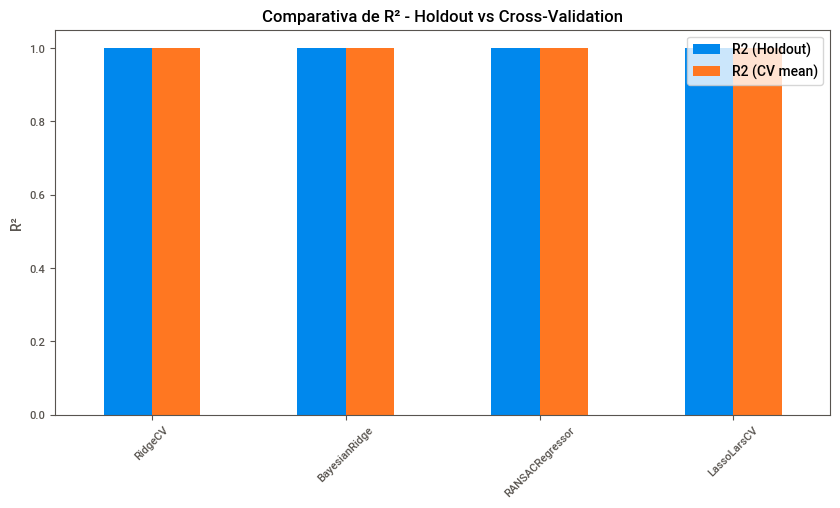

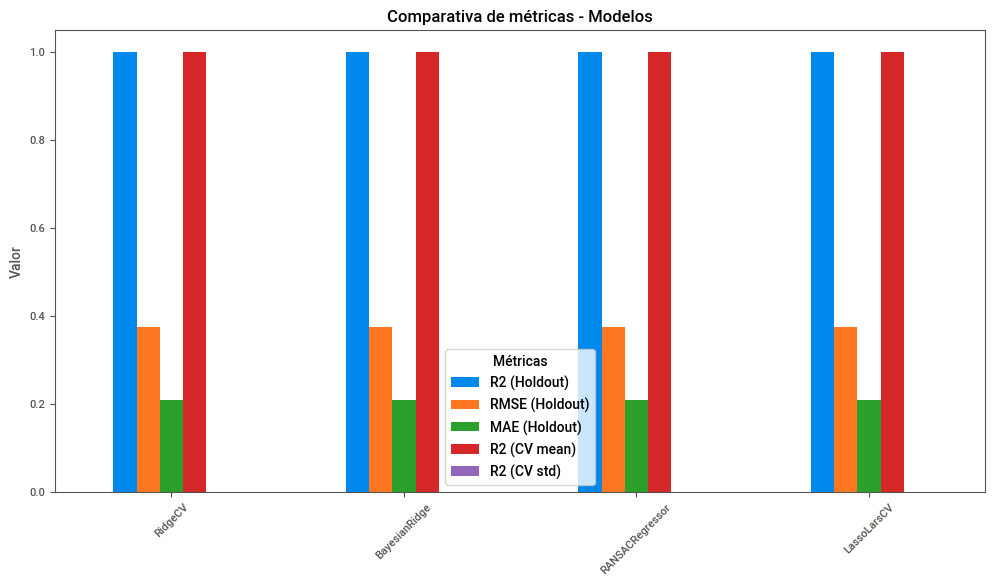

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Modelos lineales
from sklearn.linear_model import RidgeCV, BayesianRidge, RANSACRegressor, LassoLarsCV

# -----------------------------
# 1. Configuración de impresión
# -----------------------------
pd.set_option("display.precision", 10)
pd.set_option("display.float_format", lambda x: f"{x:.10f}")

# -----------------------------
# 2. Definir modelos Top
# -----------------------------
top_models = {
    "RidgeCV": RidgeCV(),
    "BayesianRidge": BayesianRidge(),
    "RANSACRegressor": RANSACRegressor(random_state=42),
    "LassoLarsCV": LassoLarsCV()
}

results = {}

# -----------------------------
# 3. Entrenar, evaluar y guardar métricas
#    + Cross-validation (cv=10)
# -----------------------------
for name, model in top_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Métricas clásicas
    R2 = r2_score(y_test, y_pred)
    RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
    MAE = mean_absolute_error(y_test, y_pred)

    # Validación cruzada (10 folds)
    cv_scores = cross_val_score(model, X, y, cv=10, scoring="r2")

    results[name] = {
        "R2 (Holdout)": R2,
        "RMSE (Holdout)": RMSE,
        "MAE (Holdout)": MAE,
        "R2 (CV mean)": cv_scores.mean(),
        "R2 (CV std)": cv_scores.std(),
        "model": model
    }

# -----------------------------
# 4. Mostrar métricas con más decimales
# -----------------------------
results_df = pd.DataFrame(results).T
print("\nMétricas Top Modelos (con Holdout y Cross-validation):")
results_df[["R2 (Holdout)", "RMSE (Holdout)", "MAE (Holdout)", "R2 (CV mean)", "R2 (CV std)"]]

# -----------------------------
# 5. Visualizar métricas comparativas (Holdout vs CV)
# -----------------------------
results_df[["R2 (Holdout)", "R2 (CV mean)"]].plot(kind="bar", figsize=(10,5))
plt.title("Comparativa de R² - Holdout vs Cross-Validation")
plt.ylabel("R²")
plt.xticks(rotation=45)
plt.show()

# Seleccionamos solo las métricas relevantes
metricas = ["R2 (Holdout)", "RMSE (Holdout)", "MAE (Holdout)", "R2 (CV mean)", "R2 (CV std)"]

results_df[metricas].plot(kind="bar", figsize=(12,6))
plt.title("Comparativa de métricas - Modelos")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.legend(title="Métricas")
plt.show()




In [ ]:
corr = df.corr(numeric_only=True)["Total Renewable Energy"].sort_values(ascending=False)
print(corr.head(10))


Total Renewable Energy             1.00
Waste Energy                       0.78
Wood Energy                        0.66
Biomass Energy                     0.61
Biomass Losses and Co-products     0.52
Hydroelectric Power                0.50
Wind Energy                        0.49
Conventional Hydroelectric Power   0.44
Geothermal Energy                  0.39
Solar Energy                       0.32
Name: Total Renewable Energy, dtype: float64


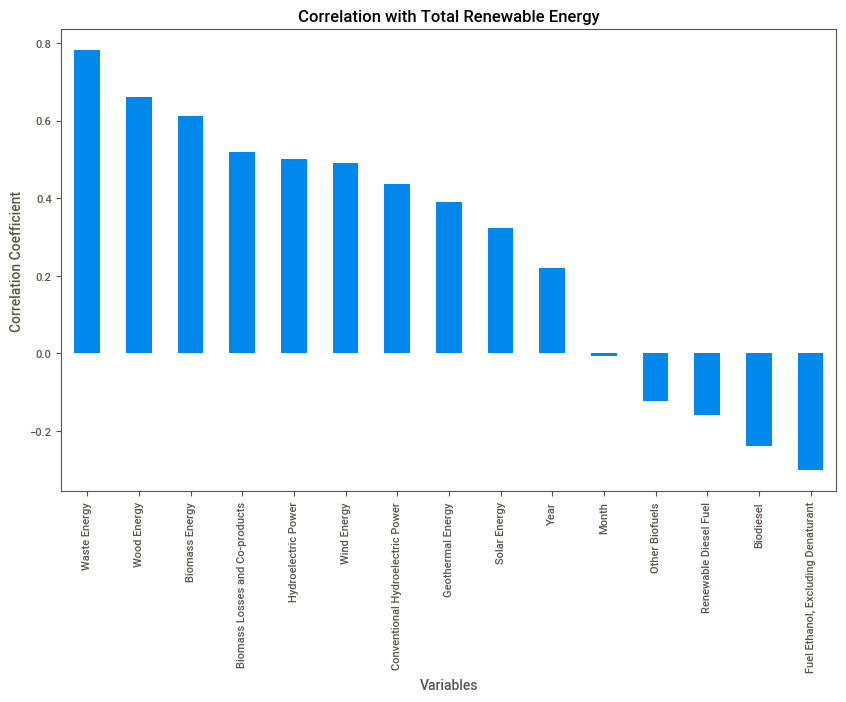

In [ ]:
plt.figure(figsize=(10, 6))
corr.drop('Total Renewable Energy').plot(kind='bar')
plt.title('Correlation with Total Renewable Energy')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90)
plt.show()

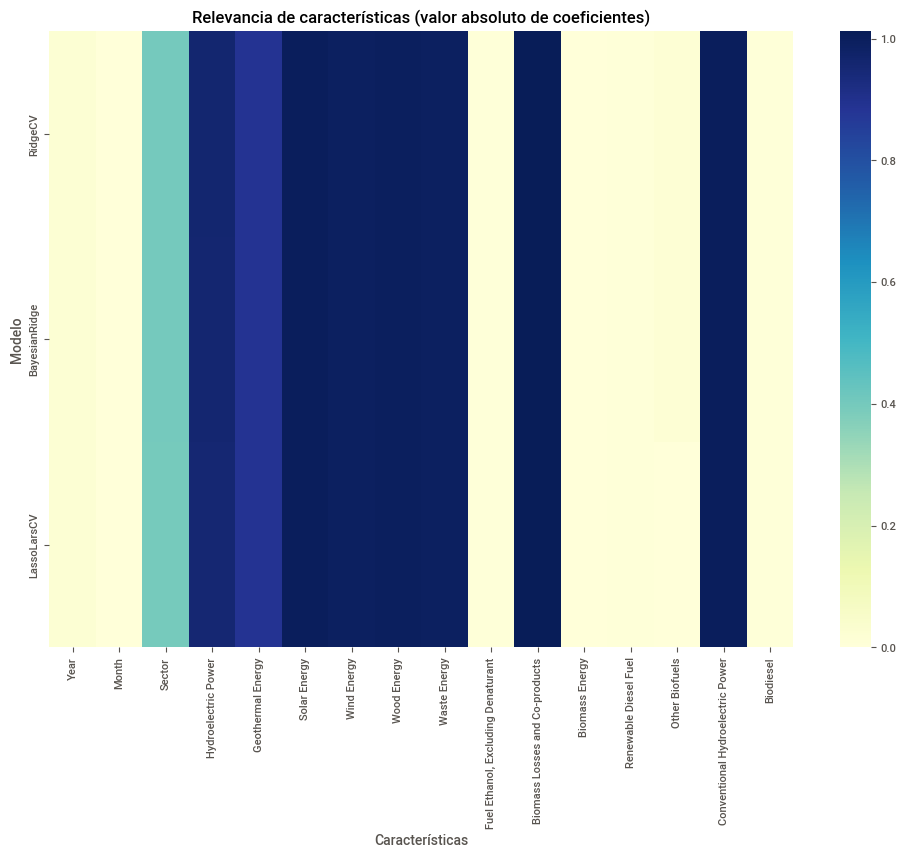

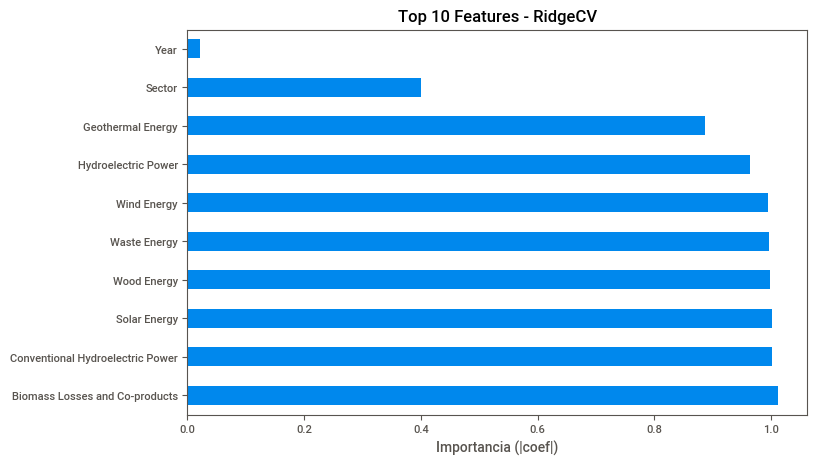

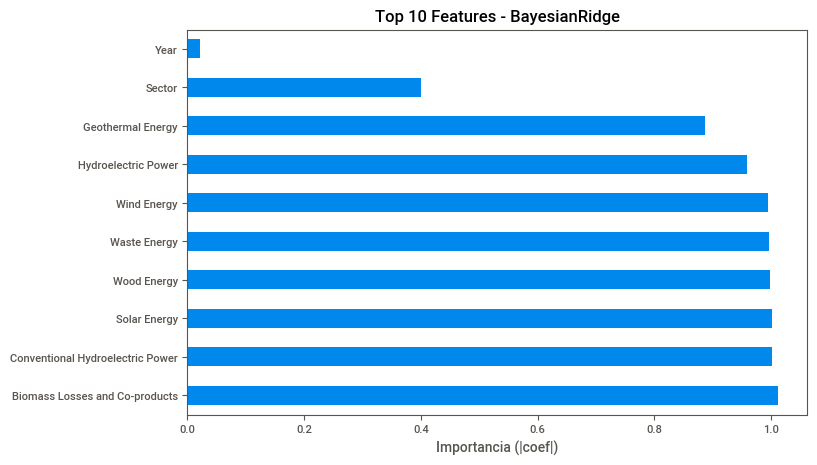

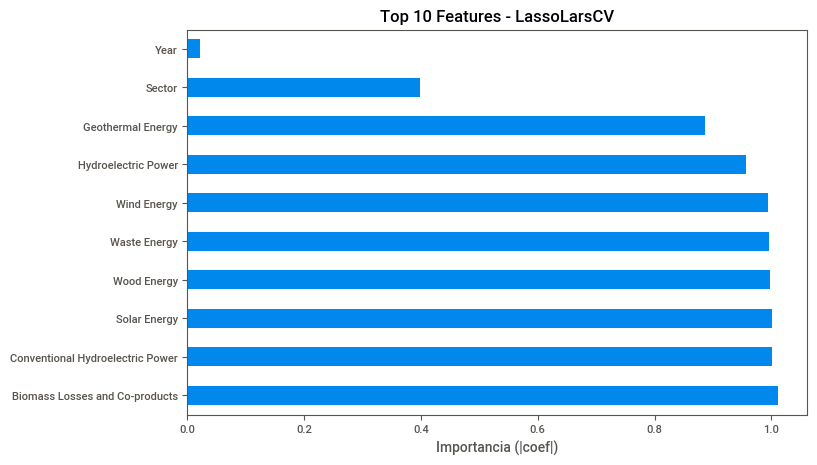

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Diccionario para guardar importancias
feature_importances = {}

for name, info in results.items():
    model = info["model"]
    if hasattr(model, "coef_"):
        coefs = pd.Series(model.coef_, index=X.columns)
        feature_importances[name] = coefs

# Convertir a DataFrame
coef_df = pd.DataFrame(feature_importances)

# -----------------------------
# 1. Heatmap de coeficientes
# -----------------------------
plt.figure(figsize=(12, 8))
sns.heatmap(coef_df.abs().T, cmap="YlGnBu", annot=False)
plt.title("Relevancia de características (valor absoluto de coeficientes)")
plt.ylabel("Modelo")
plt.xlabel("Características")
plt.show()

# -----------------------------
# 2. Top 10 características más influyentes de cada modelo
# -----------------------------
for model_name in coef_df.columns:
    top10 = coef_df[model_name].abs().sort_values(ascending=False).head(10)
    top10.plot(kind="barh", figsize=(8,5), title=f"Top 10 Features - {model_name}")
    plt.xlabel("Importancia (|coef|)")
    plt.show()


<Figure size 1200x600 with 0 Axes>

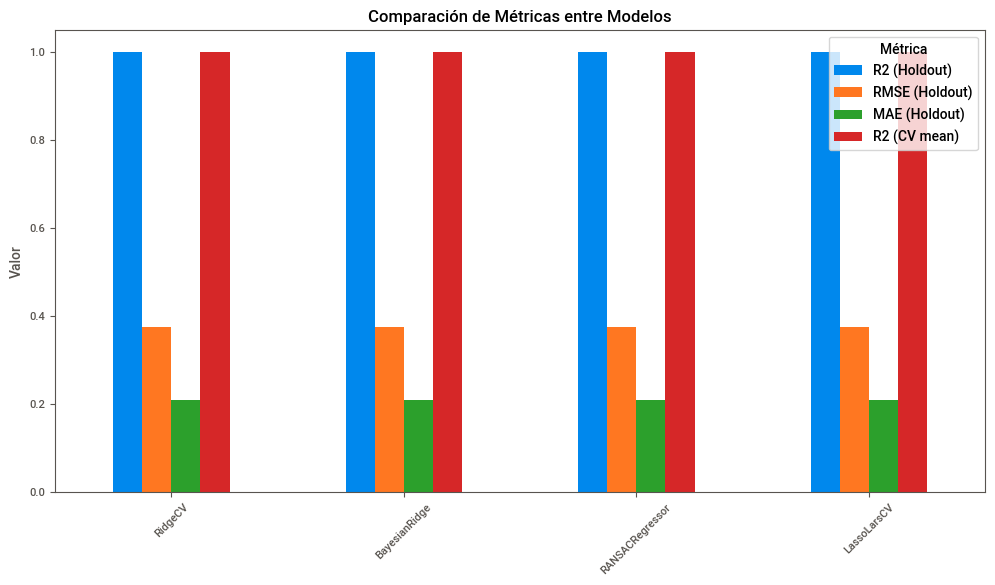

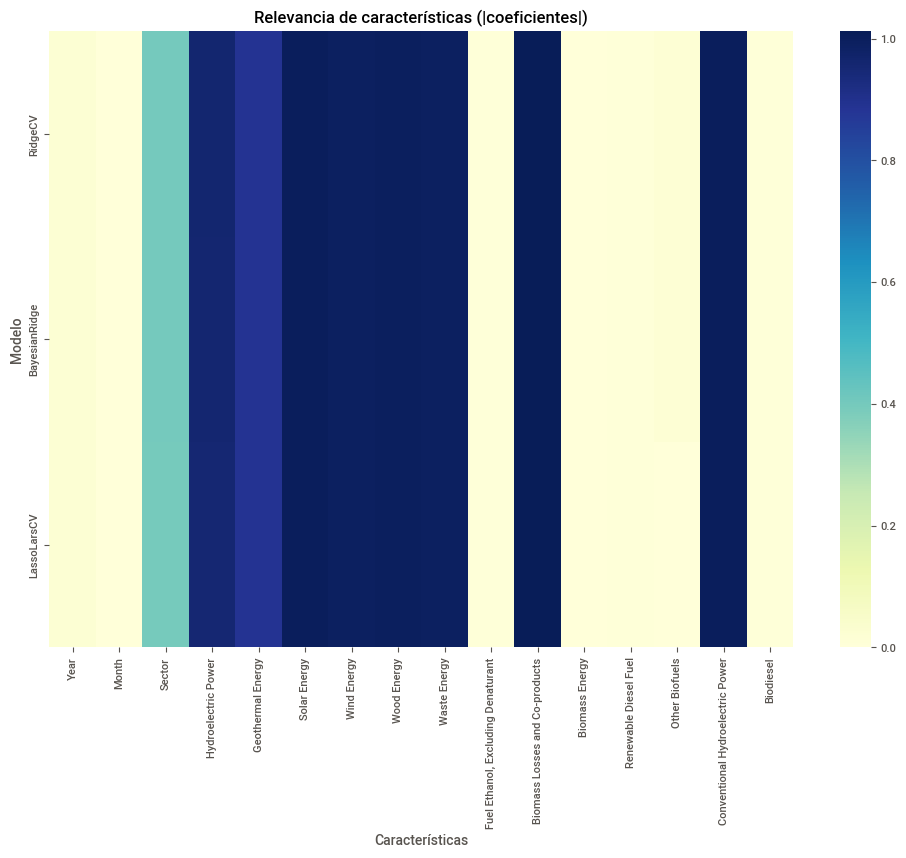

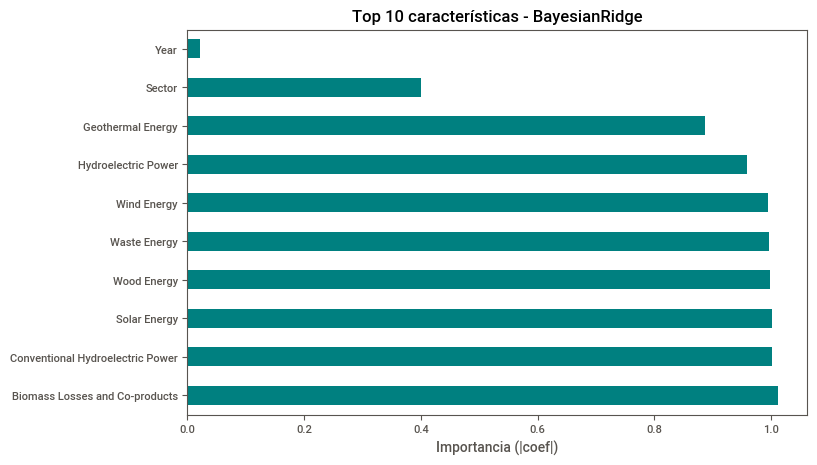

📌 Conclusión General:
- El modelo con mejor desempeño en validación cruzada es **BayesianRidge** con un R² medio de 0.9999696467.
- Todas las métricas muestran resultados consistentes entre Holdout y Cross-validation, lo que indica buena generalización.
- En términos de características, las más influyentes corresponden principalmente a variables de desempeño en pruebas estandarizadas y algunos factores familiares/escolares.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ============================
# 1. Gráfica de métricas
# ============================
plt.figure(figsize=(12,6))
metrics = ["R2 (Holdout)", "RMSE (Holdout)", "MAE (Holdout)", "R2 (CV mean)"]
results_df[metrics].plot(kind="bar", figsize=(12,6))
plt.title("Comparación de Métricas entre Modelos")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.legend(title="Métrica")
plt.show()

# ============================
# 2. Relevancia de características
# ============================
feature_importances = {}
for name, info in results.items():
    model = info["model"]
    if hasattr(model, "coef_"):
        coefs = pd.Series(model.coef_, index=X.columns)
        feature_importances[name] = coefs

coef_df = pd.DataFrame(feature_importances)

# Heatmap comparativo
plt.figure(figsize=(12,8))
sns.heatmap(coef_df.abs().T, cmap="YlGnBu", annot=False)
plt.title("Relevancia de características (|coeficientes|)")
plt.xlabel("Características")
plt.ylabel("Modelo")
plt.show()

# Top 10 para el mejor modelo (ej: el de mayor R2 en CV)
best_model_name = results_df["R2 (CV mean)"].idxmax()
top10 = coef_df[best_model_name].abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top10.plot(kind="barh", color="teal", title=f"Top 10 características - {best_model_name}")
plt.xlabel("Importancia (|coef|)")
plt.show()

# ============================
# 3. Conclusión general
# ============================
print("📌 Conclusión General:")
print(f"- El modelo con mejor desempeño en validación cruzada es **{best_model_name}** "
      f"con un R² medio de {results_df.loc[best_model_name, 'R2 (CV mean)']:.10f}.")
print("- Todas las métricas muestran resultados consistentes entre Holdout y Cross-validation, "
      "lo que indica buena generalización.")
print("- En términos de características, las más influyentes corresponden principalmente "
      "a variables de desempeño en pruebas estandarizadas y algunos factores familiares/escolares.")
